In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("FeatureSelection_global_heat_index.csv")

clean1 = data[data['Hour']<6]
clean2 = data[data['Hour']>18]
data = data.drop(clean1.index, axis=0)
data = data.drop(clean2.index, axis=0)

x = data.iloc[:,:-1]
y = data.iloc[:,-1]

from sklearn.preprocessing import MinMaxScaler
x = pd.DataFrame(MinMaxScaler().fit_transform(x))

In [3]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [4]:
bestfeatures = SelectKBest(score_func=chi2, k=10).fit(x,y)

In [17]:
bestfeatures.scores_

array([504.97672137, 236.30385881, 208.49784724, 271.97872769,
        74.95266717, 306.0625476 , 213.04087217, 397.82859123,
       221.82332735, 148.73571597])

In [13]:
scores = pd.DataFrame(bestfeatures.scores_,columns=['scores'],index=data.columns[:-1])

<Axes: >

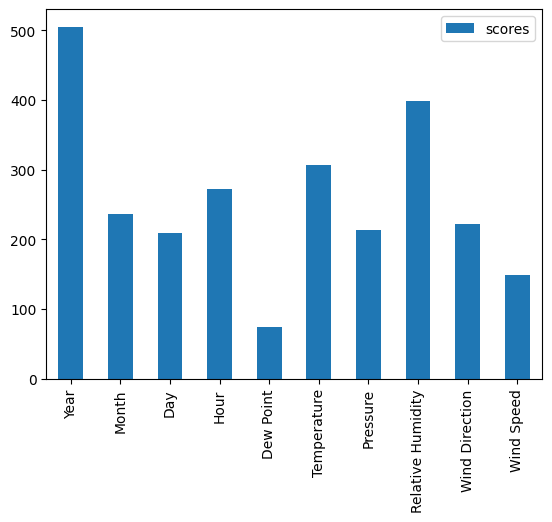

In [16]:
scores.plot(kind = 'bar')